# 📊 RetailPulse — Stationarity & ACF/PACF Analysis
## Objective
Check if the time series is stationary, perform statistical tests,
and identify ARIMA parameters (p, d, q) for forecasting.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Loading cleaned dataset
df = pd.read_csv('../data/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Creating monthly sales time series
monthly_sales = df.groupby('Month_Year')['Sales'].sum()
monthly_sales.index = pd.PeriodIndex(monthly_sales.index, freq='M')
monthly_sales = monthly_sales.sort_index()
monthly_sales.index = monthly_sales.index.to_timestamp()

print("✅ Data loaded successfully!")
print("Shape:", monthly_sales.shape)

✅ Data loaded successfully!
Shape: (48,)


## 1. Visual Stationarity Check
Plotting rolling mean and standard deviation to visually 
inspect if the time series is stationary.

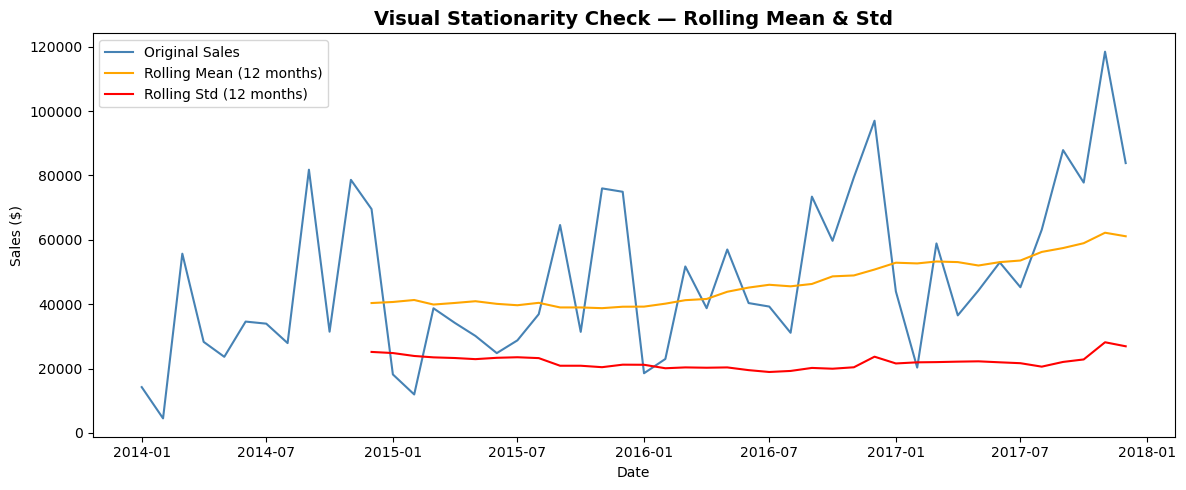

In [2]:
# Rolling mean and standard deviation
rolling_mean = monthly_sales.rolling(window=12).mean()
rolling_std = monthly_sales.rolling(window=12).std()

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales, color='steelblue', label='Original Sales')
plt.plot(rolling_mean, color='orange', label='Rolling Mean (12 months)')
plt.plot(rolling_std, color='red', label='Rolling Std (12 months)')
plt.title('Visual Stationarity Check — Rolling Mean & Std', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 2. ADF Test — Statistical Stationarity Check
Augmented Dickey-Fuller test to statistically confirm 
whether the time series is stationary or not.

In [3]:
# ADF Test
result = adfuller(monthly_sales)

print("ADF Test Results:")
print("=" * 40)
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print("-" * 40)

if result[1] < 0.05:
    print("✅ Data is STATIONARY (p < 0.05)")
else:
    print("❌ Data is NON-STATIONARY (p > 0.05)")
    print("→ Differencing required!")

ADF Test Results:
ADF Statistic : -4.4938
p-value       : 0.0002
----------------------------------------
✅ Data is STATIONARY (p < 0.05)


## 3. ACF & PACF Plots
Identifying optimal ARIMA parameters (p, q) using 
AutoCorrelation and Partial AutoCorrelation plots.

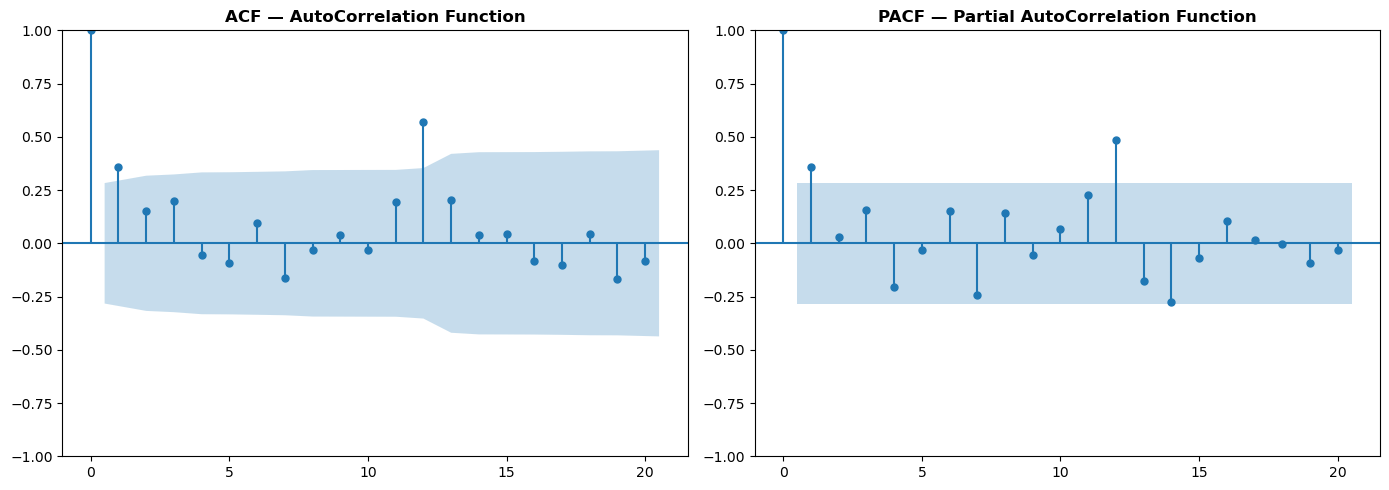

In [4]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(monthly_sales, lags=20, ax=axes[0])
axes[0].set_title('ACF — AutoCorrelation Function', fontweight='bold')

plot_pacf(monthly_sales, lags=20, ax=axes[1])
axes[1].set_title('PACF — Partial AutoCorrelation Function', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Key Findings
Summary of stationarity analysis and ARIMA parameter selection.

In [5]:
print("Key Findings:")
print("=" * 45)
print("1. Visual check → Rolling mean is increasing")
print("   → Suggests non-stationarity")
print("2. ADF Test → p-value = 0.0002 (< 0.05)")
print("   → Data is Stationary ✅")
print("3. ACF Plot → Significant at lag 1 → q = 1")
print("4. PACF Plot → Significant at lag 1 → p = 1")
print("5. ADF confirms d = 0 (no differencing needed)")
print("-" * 45)
print("✅ ARIMA Parameters: p=1, d=0, q=1")
print("→ Ready for Forecasting in Notebook 04!")

Key Findings:
1. Visual check → Rolling mean is increasing
   → Suggests non-stationarity
2. ADF Test → p-value = 0.0002 (< 0.05)
   → Data is Stationary ✅
3. ACF Plot → Significant at lag 1 → q = 1
4. PACF Plot → Significant at lag 1 → p = 1
5. ADF confirms d = 0 (no differencing needed)
---------------------------------------------
✅ ARIMA Parameters: p=1, d=0, q=1
→ Ready for Forecasting in Notebook 04!
